# Experiment No. 6

## Title
**To create an OpenCV-Python program to enhance contrast of a given RGB/Grayscale image**

## Objective
To improve the contrast of both grayscale and RGB images using linear transformation.

## Mathematical Theory
Contrast enhancement is performed by scaling pixel intensity using a constant factor.

For grayscale image:

$$
g(x,y) = \alpha f(x,y)
$$

For RGB image:

$$
g(x,y,c) = \alpha f(x,y,c)
$$

Where:

- $f(x,y)$ = input pixel value  
- $g(x,y)$ = output pixel value  
- $\alpha$ = contrast factor  
- $c$ = color channel (Red, Green, Blue)

If $\alpha > 1$, contrast increases.  
If $\alpha < 1$, contrast decreases.

To maintain valid intensity range:

$$
g(x,y) = \min(\alpha f(x,y),\ 255)
$$

## Instruments / Requirements
- Computer or Laptop  
- Python  
- OpenCV  
- NumPy  
- Matplotlib  
- Input image: `demo_image.jpg`

## Procedure
1. Read the image using OpenCV (grayscale or color).
2. If the image is color, convert it from BGR to RGB format.
3. Define a contrast factor.
4. Multiply each pixel (and each channel for RGB) by the factor.
5. Clip values to the range 0–255.
6. Store the result in a new image.
7. Display the original and contrast-enhanced images.

## Output
- Original image (Grayscale/RGB)  
- Contrast enhanced image  

## Result
The contrast-enhanced image shows increased difference between dark and bright regions. In RGB images, contrast is enhanced uniformly across all color channels.

## Conclusion
Contrast enhancement improves image quality by increasing intensity differences. It is useful for highlighting important features and works for both grayscale and RGB images.

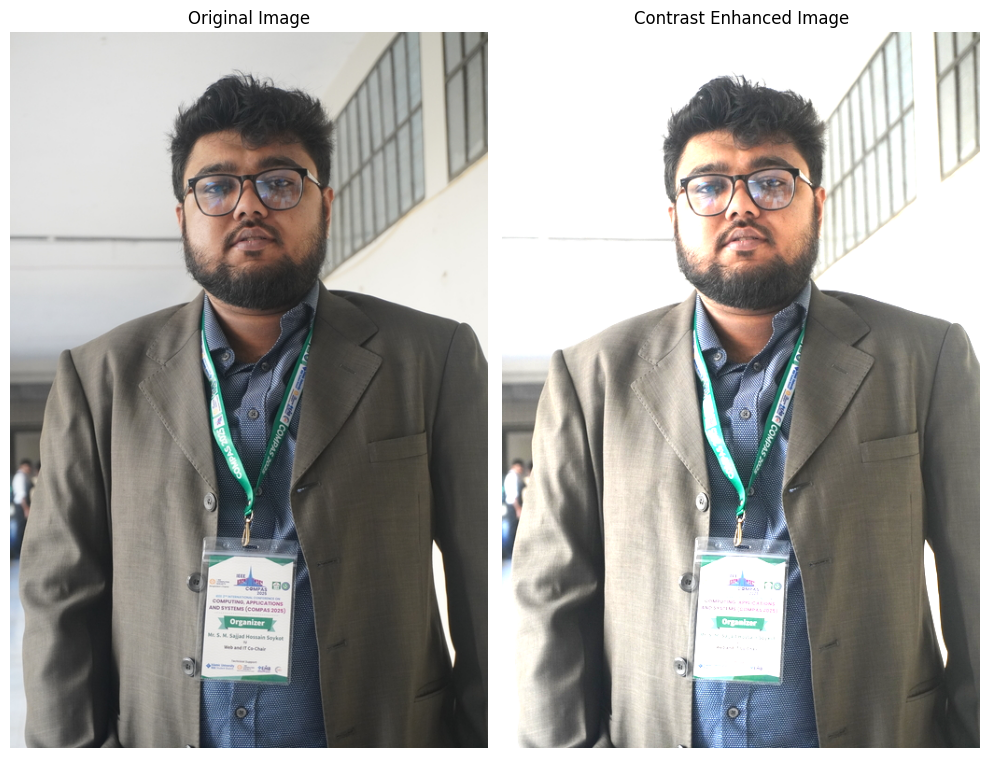

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image (color by default)
img = cv2.imread('demo_image.jpg')

alpha = 1.5  # Contrast factor

# Check grayscale or color
if len(img.shape) == 2:
    # Grayscale
    h, w = img.shape
    contrast = np.zeros((h, w), dtype=np.uint8)

    for i in range(h):
        for j in range(w):
            value = int(alpha * img[i, j])
            if value > 255:
                value = 255
            contrast[i, j] = value

    display_img = img
    display_contrast = contrast
    cmap = 'gray'

else:
    # Color image
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, c = img.shape
    contrast = np.zeros((h, w, c), dtype=np.uint8)

    for i in range(h):
        for j in range(w):
            for k in range(c):
                value = int(alpha * img[i, j, k])
                if value > 255:
                    value = 255
                contrast[i, j, k] = value

    display_img = img
    display_contrast = contrast
    cmap = None

# Display
plt.figure(figsize=(10, 8))

plt.subplot(1, 2, 1)
plt.imshow(display_img, cmap=cmap)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(display_contrast, cmap=cmap)
plt.title("Contrast Enhanced Image")
plt.axis("off")

plt.tight_layout()
plt.savefig('Exp6_Output.png')  # Save full figure
plt.show()